In [62]:
# Import de librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
from scipy.stats import skew, kurtosis


In [111]:
# path a los archivos parquet
##files = glob.glob("../dataset/*.parquet")
files = glob.glob("../dataset/06-new-variables/yellow_tripdata_2024-01.parquet")
# leer .parquet files y concatenar en un solo df 
df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)

print(len(files), "files merged")
print(df.shape)

# Formato de visualización de floats en pandas
pd.set_option('display.float_format', '{:.2f}'.format)

1 files merged
(2533274, 25)


In [112]:
df['pickup_day'] = df['tpep_pickup_datetime'].dt.day
df['pickup_hr'] = df['tpep_pickup_datetime'].dt.hour
df['weekday'] = df['tpep_pickup_datetime'].dt.weekday # monday = 0, sunday = 6

df['dropoff_day'] = df['tpep_dropoff_datetime'].dt.day
df['dropoff_hr'] = df['tpep_dropoff_datetime'].dt.hour

df['revenue'] = df['fare_amount'] + df['tip_amount']

df.head(2)

,vendor,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,ratecode,payment_type,fare_amount,extra,mta_tax,tip_amount,...,pickup_hour,hour_bin,log_trip_distance,total_amount_calculated,pickup_day,pickup_hr,weekday,dropoff_day,dropoff_hr,revenue
0,"Curb Mobility, LLC",2024-01-01 00:57:55,2024-01-01 01:17:43,1,Standard rate,Cash,17.70,1.00,0.50,0.00,...,0,0-2,1.00,22.70,1,0,0,1,1,17.70
1,"Creative Mobile Technologies, LLC",2024-01-01 00:03:00,2024-01-01 00:09:36,1,Standard rate,Credit card,10.00,3.50,0.50,3.75,...,0,0-2,1.03,21.25,1,0,0,1,0,13.75


In [113]:
# dropeamos columnas q forman revenue
df.drop(columns=['fare_amount', 'tip_amount'], inplace=True)
# dropeamos variables futuras
df.drop(columns=[ 'dropoff_borough', 'dropoff_service_zone','dropoff_day','dropoff_hr', 'tpep_pickup_datetime','tpep_dropoff_datetime', 'dropoff_zone','vendor', 'passenger_count', 'ratecode', 'payment_type', 'pickup_service_zone','pickup_borough','hour_bin','total_amount','total_amount_calculated', 'pickup_hour'], inplace=True)
df.head(2)

,extra,mta_tax,tolls_amount,improvement_surcharge,congestion_surcharge,Airport_fee,pickup_zone,log_trip_distance,pickup_day,pickup_hr,weekday,revenue
0,1.00,0.50,0.00,1.00,2.50,0.00,Penn Station/Madison Sq West,1.00,1,0,0,17.70
1,3.50,0.50,0.00,1.00,2.50,0.00,Lenox Hill East,1.03,1,0,0,13.75


In [114]:
# convertir hora, dia, weekday a categoricas
df['pickup_hr'] = df['pickup_hr'].astype('category')
df['pickup_day'] = df['pickup_day'].astype('category')
df['weekday'] = df['weekday'].astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2533274 entries, 0 to 2533273
Data columns (total 12 columns):
 #   Column                 Dtype   
---  ------                 -----   
 0   extra                  float64 
 1   mta_tax                float64 
 2   tolls_amount           float64 
 3   improvement_surcharge  float64 
 4   congestion_surcharge   float64 
 5   Airport_fee            float64 
 6   pickup_zone            category
 7   log_trip_distance      float64 
 8   pickup_day             category
 9   pickup_hr              category
 10  weekday                category
 11  revenue                float64 
dtypes: category(4), float64(8)
memory usage: 166.7 MB


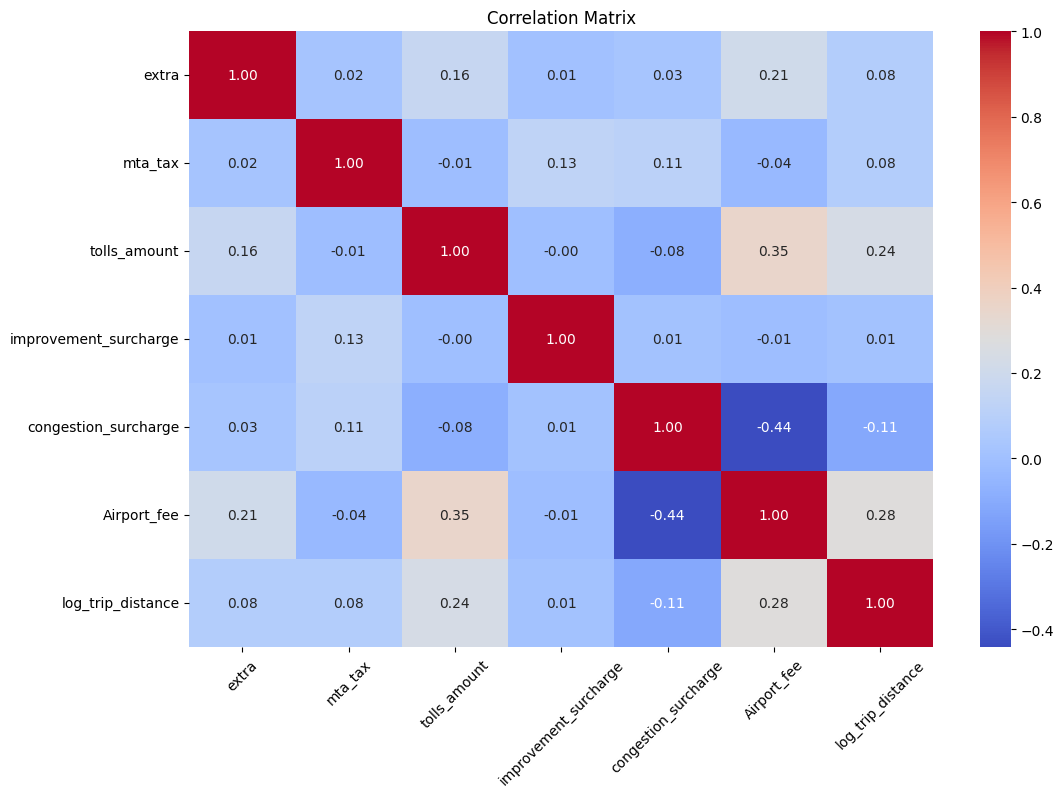

In [115]:
# numeric columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove('revenue')  # Exclude target variable if needed
# correlation matrix para numeric features
corr = df[num_cols].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.xticks(rotation=45)
plt.title('Correlation Matrix')
plt.show()


In [116]:
# para seleccionar features numericas usamos spearman 

from scipy.stats import spearmanr
import pandas as pd

X_num = df[num_cols]
y = df['revenue']

scores = []
pvalues = []

for col in num_cols:
    corr, pval = spearmanr(df[col], y)
    scores.append(corr)
    pvalues.append(pval)

num_feature_scores = pd.DataFrame({
    'Feature': num_cols,
    'Spearman_corr': scores,
    'p-value': pvalues
}).sort_values(by='Spearman_corr', ascending=False)

print("Numerical Feature Scores (Spearman):")
print(num_feature_scores)



Numerical Feature Scores (Spearman):
                 Feature  Spearman_corr  p-value
6      log_trip_distance           0.85     0.00
5            Airport_fee           0.17     0.00
2           tolls_amount           0.16     0.00
0                  extra          -0.00     0.00
3  improvement_surcharge          -0.01     0.00
1                mta_tax          -0.05     0.00
4   congestion_surcharge          -0.08     0.00


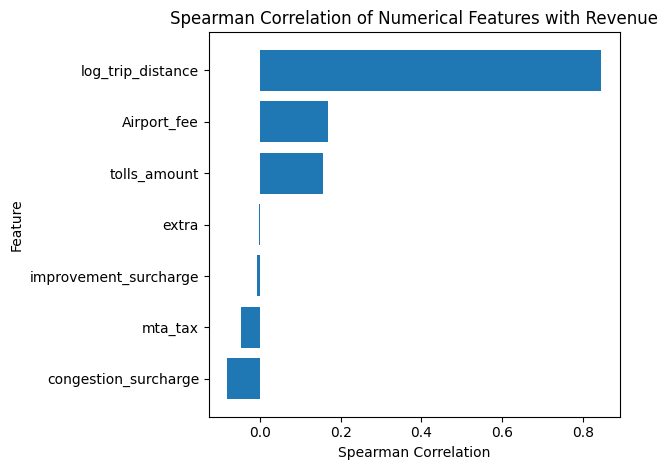

In [117]:
import matplotlib.pyplot as plt

plt.figure()
plt.barh(num_feature_scores["Feature"], num_feature_scores["Spearman_corr"])
plt.xlabel("Spearman Correlation")
plt.ylabel("Feature")
plt.title("Spearman Correlation of Numerical Features with Revenue")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [118]:
# tomamos features por encima de abs(spearman_corr) >= 0.1
selected_num_features = num_feature_scores[ num_feature_scores['Spearman_corr'].abs() >= 0.1 ]['Feature'].tolist()
print("Selected Numerical Features:", selected_num_features)
# filtramos dataset
df_reduced_num = df[selected_num_features + ['revenue']]
print("Reduced DataFrame shape:", df_reduced_num.shape)
df_reduced_num.head(2)

Selected Numerical Features: ['log_trip_distance', 'Airport_fee', 'tolls_amount']
Reduced DataFrame shape: (2533274, 4)


,log_trip_distance,Airport_fee,tolls_amount,revenue
0,1.00,0.00,0.00,17.70
1,1.03,0.00,0.00,13.75


In [119]:
from sklearn.feature_selection import f_regression
import category_encoders as ce
import numpy as np
import pandas as pd

# =========================
# TARGET
# =========================
y = df['revenue']

# =========================
# COPIA DE SEGURIDAD
# =========================
df_tmp = df.copy()

# =========================
# 1️⃣ CYCLIC ENCODING
# =========================
cyclic_features = {
    'weekday': 7,     # 0–6
    'pickup_day': 31, # 1–31
    'pickup_hr': 24   # 0–23
}

# Convertir a entero antes de sin/cos
for col in cyclic_features.keys():
    df_tmp[col] = df_tmp[col].astype(int)

# Aplicar cyclic encoding
for col, max_val in cyclic_features.items():
    if col == 'pickup_day':
        df_tmp[f'{col}_sin'] = np.sin(2 * np.pi * (df_tmp[col] - 1) / max_val)
        df_tmp[f'{col}_cos'] = np.cos(2 * np.pi * (df_tmp[col] - 1) / max_val)
    else:
        df_tmp[f'{col}_sin'] = np.sin(2 * np.pi * df_tmp[col] / max_val)
        df_tmp[f'{col}_cos'] = np.cos(2 * np.pi * df_tmp[col] / max_val)

# Eliminar columnas originales cíclicas
df_tmp = df_tmp.drop(columns=cyclic_features.keys())

# =========================
# 2️⃣ BINARY ENCODING
# =========================
binary_encoder = ce.BinaryEncoder(cols=['pickup_zone'])
df_tmp = binary_encoder.fit_transform(df_tmp)

# =========================
# 3️⃣ ANOVA PARA REGRESIÓN
# =========================
X_encoded = df_tmp.copy()

f_values, p_values = f_regression(X_encoded, y)

anova_feature_scores = pd.DataFrame({
    'Feature': X_encoded.columns,
    'F_value': f_values,
    'p-value': p_values
}).sort_values(by='F_value', ascending=False)

print("ANOVA sobre features ya encodeadas (Cyclic + Binary):")
print(anova_feature_scores)


ANOVA sobre features ya encodeadas (Cyclic + Binary):
                  Feature                F_value  p-value
15                revenue 2068693170483071744.00     0.00
14      log_trip_distance             5371035.79     0.00
5             Airport_fee              122958.77     0.00
2            tolls_amount              113840.58     0.00
4    congestion_surcharge               28276.89     0.00
8           pickup_zone_2               16107.74     0.00
6           pickup_zone_0                8924.30     0.00
1                 mta_tax                8013.89     0.00
7           pickup_zone_1                3125.39     0.00
0                   extra                2176.68     0.00
16            weekday_sin                1622.28     0.00
13          pickup_zone_7                1568.24     0.00
21          pickup_hr_cos                1460.35     0.00
17            weekday_cos                1228.58     0.00
10          pickup_zone_4                 955.90     0.00
18         pickup_

In [120]:
# ================================
# AGRUPACIÓN DE RESULTADOS ANOVA
# A NIVEL DE VARIABLE ORIGINAL (POST-ENCODING)
# ================================

# 1. Extraer la variable base desde el nombre de la columna codificada
anova_feature_scores['base_feature'] = (
    anova_feature_scores['Feature']
    .str.extract(r'^(pickup_zone|weekday|pickup_day|pickup_hr)')
)

# 2. Eliminar filas que no pertenezcan a estas variables (por seguridad)
anova_feature_scores = anova_feature_scores.dropna(subset=['base_feature'])

# 3. Agrupar por variable original usando:
#    - Máximo F_value (mayor impacto)
#    - Mínimo p-value (mayor significancia)
cat_grouped = anova_feature_scores.groupby('base_feature').agg({
    'F_value': 'max',
    'p-value': 'min'
}).sort_values(by='F_value', ascending=False)

print("✅ ANOVA agrupado por variable categórica original (post-encoding):")
print(cat_grouped)

# 4. Selección estadística final de categóricas
cat_features_finales = cat_grouped[cat_grouped['p-value'] < 0.05].index.tolist()

print("\n✅ Variables categóricas seleccionadas:")
print(cat_features_finales)


✅ ANOVA agrupado por variable categórica original (post-encoding):
              F_value  p-value
base_feature                  
pickup_zone  16107.74     0.00
weekday       1622.28     0.00
pickup_hr     1460.35     0.00
pickup_day     624.12     0.00

✅ Variables categóricas seleccionadas:
['pickup_zone', 'weekday', 'pickup_hr', 'pickup_day']


In [121]:
# tomamos faeturs con f_value > 500 
selected_cat_features = cat_grouped[ cat_grouped['F_value'] > 500 ].index.tolist()
print("Selected Categorical Features:", selected_cat_features)
# añadimos a dataset
df_reduced_cat = df[selected_cat_features + ['revenue']]
print("Reduced Categorical DataFrame shape:", df_reduced_cat.shape)


Selected Categorical Features: ['pickup_zone', 'weekday', 'pickup_hr', 'pickup_day']
Reduced Categorical DataFrame shape: (2533274, 5)


In [122]:
# merge de dataframes reducidos
df_reduced = pd.concat([df_reduced_num, df_reduced_cat.drop(columns=['revenue'])], axis=1)
print("Final Reduced DataFrame shape:", df_reduced.shape)
df_reduced.head(2)

Final Reduced DataFrame shape: (2533274, 8)


,log_trip_distance,Airport_fee,tolls_amount,revenue,pickup_zone,weekday,pickup_hr,pickup_day
0,1.00,0.00,0.00,17.70,Penn Station/Madison Sq West,0,0,1
1,1.03,0.00,0.00,13.75,Lenox Hill East,0,0,1


In [123]:
import numpy as np
import pandas as pd

# Variables cíclicas con su período
cyclic_features = {
    'weekday': 7,     # 0–6
    'pickup_day': 31, # 1–31
    'pickup_hr': 24   # 0–23
}

df_tmp = df_reduced.copy()

# 🔥 Convertir explícitamente a entero antes del encoding
for col in cyclic_features.keys():
    df_tmp[col] = df_tmp[col].astype(int)

# Aplicar cyclic encoding correcto
for col, max_val in cyclic_features.items():
    if col == 'pickup_day':
        df_tmp[f'{col}_sin'] = np.sin(2 * np.pi * (df_tmp[col] - 1) / max_val)
        df_tmp[f'{col}_cos'] = np.cos(2 * np.pi * (df_tmp[col] - 1) / max_val)
    else:
        df_tmp[f'{col}_sin'] = np.sin(2 * np.pi * df_tmp[col] / max_val)
        df_tmp[f'{col}_cos'] = np.cos(2 * np.pi * df_tmp[col] / max_val)

# Eliminar columnas originales
df_reduced_encoded = df_tmp.drop(columns=cyclic_features.keys())

df_reduced_encoded.head(2)


,log_trip_distance,Airport_fee,tolls_amount,revenue,pickup_zone,weekday_sin,weekday_cos,pickup_day_sin,pickup_day_cos,pickup_hr_sin,pickup_hr_cos
0,1.00,0.00,0.00,17.70,Penn Station/Madison Sq West,0.00,1.00,0.00,1.00,0.00,1.00
1,1.03,0.00,0.00,13.75,Lenox Hill East,0.00,1.00,0.00,1.00,0.00,1.00


In [ ]:
# pickup_zone binary encoding
# pickup_zone
binary_encoder = ce.BinaryEncoder(cols=['pickup_zone'])
df_reduced_encoded = binary_encoder.fit_transform(df_reduced_encoded)
df_reduced_encoded.head(2)


ValueError: X does not contain the columns listed in cols

In [132]:
df_reduced_encoded.head(10)

,log_trip_distance,Airport_fee,tolls_amount,revenue,pickup_zone_0,pickup_zone_1,pickup_zone_2,pickup_zone_3,pickup_zone_4,pickup_zone_5,pickup_zone_6,pickup_zone_7,weekday_sin,weekday_cos,pickup_day_sin,pickup_day_cos,pickup_hr_sin,pickup_hr_cos
0,1.00,0.00,0.00,17.70,0,0,0,0,0,0,0,1,0.00,1.00,0.00,1.00,0.00,1.00
1,1.03,0.00,0.00,13.75,0,0,0,0,0,0,1,0,0.00,1.00,0.00,1.00,0.00,1.00
2,1.74,0.00,0.00,26.30,0,0,0,0,0,0,1,1,0.00,1.00,0.00,1.00,0.00,1.00
3,0.88,0.00,0.00,12.00,0,0,0,0,0,1,0,0,0.00,1.00,0.00,1.00,0.00,1.00
4,0.59,0.00,0.00,11.10,0,0,0,0,0,1,0,1,0.00,1.00,0.00,1.00,0.00,1.00
5,1.74,0.00,0.00,36.50,0,0,0,0,0,1,1,0,0.00,1.00,0.00,1.00,0.00,1.00
6,1.86,0.00,0.00,29.60,0,0,0,0,0,1,1,1,0.00,1.00,0.00,1.00,0.00,1.00
7,0.04,0.00,0.00,3.00,0,0,0,0,1,0,0,0,0.00,1.00,0.00,1.00,0.00,1.00
8,0.56,0.00,0.00,7.90,0,0,0,0,1,0,0,1,0.00,1.00,0.00,1.00,0.00,1.00
9,0.79,0.00,0.00,18.85,0,0,0,0,1,0,1,0,0.00,1.00,0.00,1.00,0.00,1.00


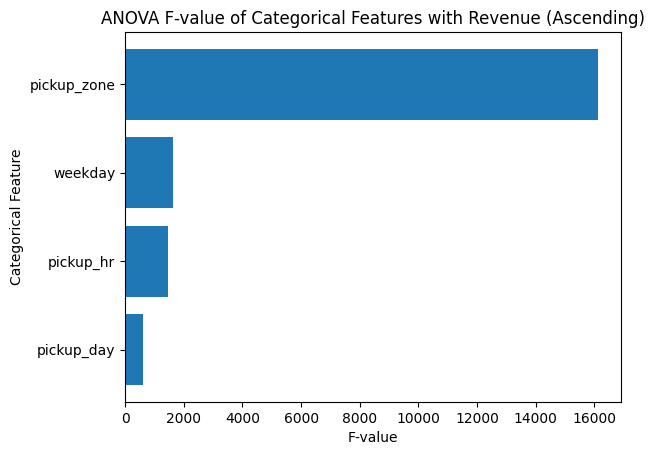

In [128]:
# Orden ascendente por F-value
cat_grouped_sorted = cat_grouped.sort_values(by='F_value', ascending=True)

# Gráfico de barras horizontal
plt.figure()
plt.barh(cat_grouped_sorted.index, cat_grouped_sorted['F_value'])
plt.xlabel("F-value")
plt.ylabel("Categorical Feature")
plt.title("ANOVA F-value of Categorical Features with Revenue (Ascending)")
plt.show()


In [130]:
# exportamos df limpio en formato parquet. para esto separamos por mes para no tener archivos muy grandes
df_reduced_encoded.to_parquet(f"../dataset/07-reduced-dim/yellow_tripdata_2024-01.parquet", index=False)


In [33]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_classif
from scipy.stats import f_oneway

# -----------------------------------------------------------
# 1. Separar features numéricas y categóricas
# -----------------------------------------------------------

target = "pickup_zone"

numeric_features = df.select_dtypes(include=["float64"]).columns.tolist()
categorical_features = df.select_dtypes(include=["category", "object", "int32", "int64"]).columns.tolist()

# Excluir la target de ambos
if target in numeric_features:
    numeric_features.remove(target)
if target in categorical_features:
    categorical_features.remove(target)

print("Features numéricas:", numeric_features)
print("Features categóricas:", categorical_features)


Features numéricas: ['fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee', 'revenue']
Features categóricas: ['dropoff_zone', 'pickup_hour', 'pickup_day', 'pickup_hr', 'weekday', 'dropoff_day', 'dropoff_hr']


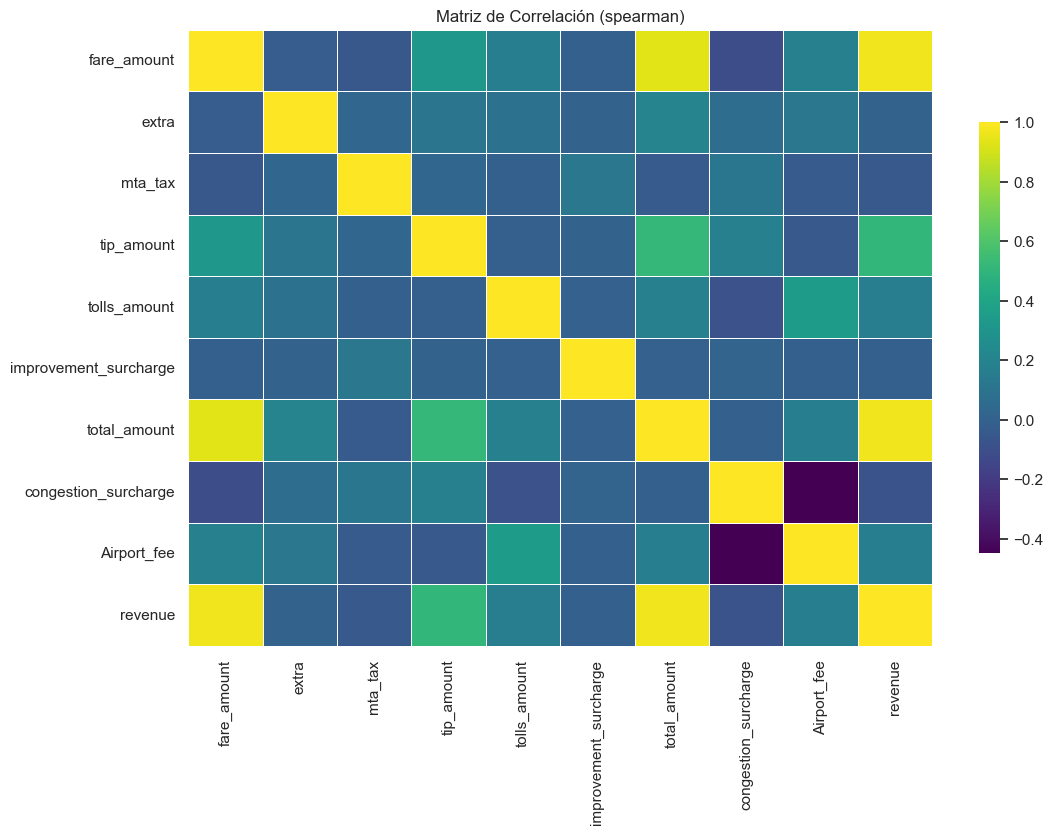

Información Mutua:


,feature,mutual_info
6,total_amount,0.15
7,congestion_surcharge,0.13
9,revenue,0.13
8,Airport_fee,0.10
1,extra,0.09
0,fare_amount,0.09
3,tip_amount,0.08
2,mta_tax,0.02
4,tolls_amount,0.02
5,improvement_surcharge,0.01


C:\Users\pc\AppData\Local\Temp\ipykernel_12348\1805716046.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mi_df, x="mutual_info", y="feature", palette="viridis")


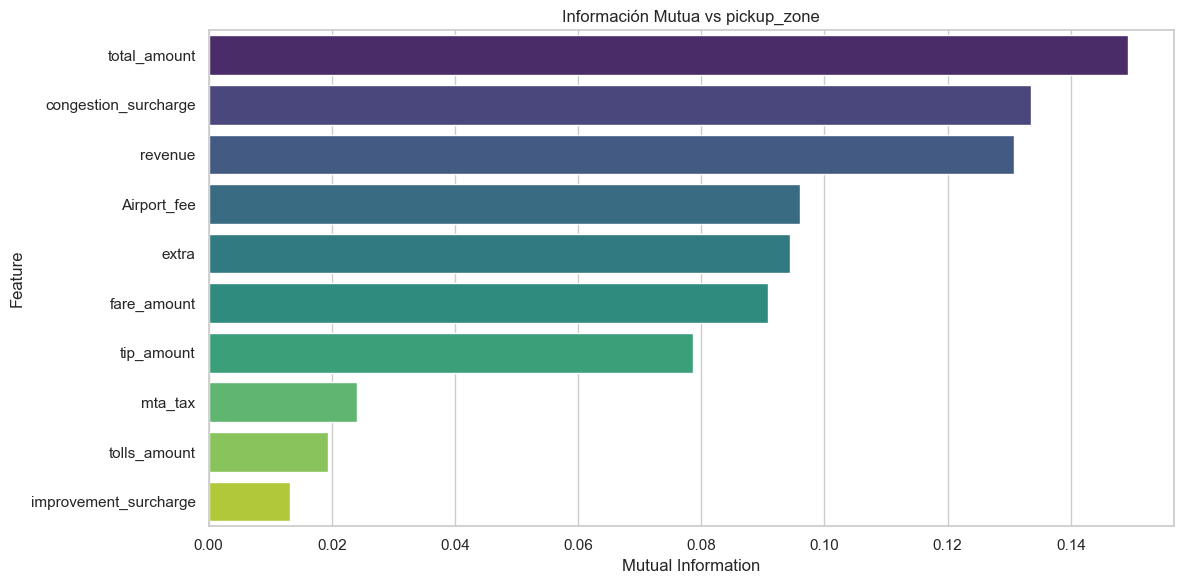

In [34]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_classif
from scipy.stats import f_oneway
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo de gráficos
sns.set(style="whitegrid", palette="viridis")


# -----------------------------------------------------------
# 2. Correlación de Pearson entre numéricas
# -----------------------------------------------------------

corr_matrix = df[numeric_features].corr(method="spearman")

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix, annot=False, cmap="viridis", 
    linewidths=0.5, cbar_kws={"shrink": 0.7}
)
plt.title("Matriz de Correlación (spearman)")
plt.show()

# -----------------------------------------------------------
# 3. Información Mutua (numéricas → target categórica)
# -----------------------------------------------------------

X = df[numeric_features]
y = df[target]

mi_scores = mutual_info_classif(X, y, discrete_features=False, random_state=42)

mi_df = pd.DataFrame({
    "feature": numeric_features,
    "mutual_info": mi_scores
}).sort_values(by="mutual_info", ascending=False)

print("Información Mutua:")
display(mi_df)

# ---- Gráfico MI ----
plt.figure(figsize=(12, 6))
sns.barplot(data=mi_df, x="mutual_info", y="feature", palette="viridis")
plt.title("Información Mutua vs pickup_zone")
plt.xlabel("Mutual Information")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()



In [35]:
from sklearn.feature_selection import mutual_info_classif

target = "pickup_zone"

# Features categóricas
categorical_features = df.select_dtypes(include=["category", "object"]).columns.tolist()
categorical_features = [c for c in categorical_features if c != target]

# one-hot encoding temporal solo para X
X_cat = pd.get_dummies(df[categorical_features], drop_first=False)

# Información mutua
mi_cat_scores = mutual_info_classif(X_cat, df[target], discrete_features=True, random_state=42)

mi_cat_df = pd.DataFrame({
    "feature": X_cat.columns,
    "mutual_info": mi_cat_scores
}).sort_values(by="mutual_info", ascending=False)

display(mi_cat_df)


KeyboardInterrupt: 

In [ ]:
# numéricas contra target categórica

from scipy.stats import f_oneway
import pandas as pd
import numpy as np

target = "pickup_zone"

# Features numéricas
numeric_features = df.select_dtypes(include=["float64", "int32", "int64"]).columns.tolist()
numeric_features = [c for c in numeric_features if c != target]

anova_results = []

# categorías de la target
categories = df[target].unique()

for col in numeric_features:
    # valores por categoría
    groups = [df[df[target] == cat][col].dropna().values for cat in categories]
    
    # ANOVA
    f_stat, p_val = f_oneway(*groups)
    anova_results.append((col, f_stat, p_val))

anova_df = pd.DataFrame(anova_results, columns=["feature", "F_statistic", "p_value"])
anova_df = anova_df.sort_values(by="p_value")

display(anova_df)

import seaborn as sns
import matplotlib.pyplot as plt

# Barplot F-statistic
plt.figure(figsize=(10, 6))
sns.barplot(data=anova_df.sort_values("F_statistic", ascending=False),
            x="F_statistic", y="feature", palette="viridis")
plt.title("ANOVA — F-statistic por feature")
plt.tight_layout()
plt.show()

# Barplot p-values en escala log
anova_plot = anova_df.copy()
anova_plot["log_p"] = -np.log10(anova_plot["p_value"])

plt.figure(figsize=(10, 6))
sns.barplot(data=anova_plot.sort_values("log_p", ascending=False),
            x="log_p", y="feature", palette="viridis")
plt.title("ANOVA — -log10(p-value) por feature")
plt.tight_layout()
plt.show()
